In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from collections import defaultdict
from scipy import stats
from scipy.spatial.distance import mahalanobis
from pathlib import Path

/misc/team2/wenzel/mamba/envs/lamah-ce_lstm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Specify the time periods.

In [2]:
discharge_coverage_path = Path("~/BA/data/processed_data/eda/discharge_coverage.pkl")

discharge_coverage = pd.read_pickle(discharge_coverage_path)

##### Visualize normal periods for a subsample of basins. 

Basin 55 is the odd one out, it shows systematic gaps, and is therefore not usable.

In [3]:
min_normal_len = 1 

In [4]:
#fig, ax = plt.subplots(figsize=(10, len(discharge_coverage) * 0.25))

yticks = []
yticklabels = []

# Test pickling. 
train_dict = defaultdict(dict)
val_dict = defaultdict(dict)
test_dict = defaultdict(dict)

for basin in discharge_coverage.itertuples():

    basin_dict = {
        "start_dates": [],
        "end_dates" : []
    }
    normal_periods = []

    for period in basin[-2]: 

        x_min = period[0]
        x_width = (period[1] - period[0])

        if x_width.days > min_normal_len: 
            normal_periods.append((x_min,x_width))

            # Attach for pickling. 
            basin_dict["start_dates"].append(period[0])
            basin_dict["end_dates"].append(period[1])

    #ax.broken_barh(xranges=normal_periods, yrange=(len(yticks), 0.5))

    basin_id = basin[0]

    if len(basin_dict["end_dates"]) != 0: 

        if basin_id < 600:
            train_dict[str(basin_id)] = basin_dict
        elif basin_id < 750: 
            val_dict[str(basin_id)] = basin_dict
        else: 
            test_dict[str(basin_id)] = basin_dict

    #yticks.append(len(yticks))
    #yticklabels.append(basin[0])

#ax.set_yticks(yticks)
#ax.set_yticklabels(yticklabels)
#ax.set_ylim(-1,len(yticks)+1)
#
#plt.tight_layout()
#plt.show()


In [5]:
n_samples = 0

for basin in discharge_coverage["q5_q95_normal_periods"]: 

    for period in basin: 

        duration = (period[1] - period[0]).days

        if duration >= min_normal_len:
            n_samples += duration

print(n_samples)

9391290


#### Specify the basin IDs.

In [6]:
# Remove NA & non-numeric columns and normalize with z-score for PCA.

scaler = preprocessing.StandardScaler()

# Load attributes and hydrologic indices.
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_attributes = basin_stca_gdf.dropna().sort_index()
numeric_attributes = no_na_attributes.select_dtypes(include=["number"])
scaled_attributes = pd.DataFrame(
    scaler.fit_transform(numeric_attributes.values),
    columns=numeric_attributes.columns,
    index=numeric_attributes.index
)

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
    scaler.fit_transform(numeric_hy_id.values),
    columns=numeric_hy_id.columns,
    index=numeric_hy_id.index
)

# Remove basins for which no hy_id exists. 
common_ids = scaled_attributes.index.intersection(scaled_hy_id.index)
scaled_attributes = scaled_attributes.loc[common_ids]
scaled_hy_id = scaled_hy_id.loc[common_ids]

In [7]:
# Calculate Malahanobis distance, to check if basins are outliers. 
np.linalg.cond(scaled_attributes.corr()) < 10e10

attributes_values = scaled_attributes.values

mu = np.mean(attributes_values, axis=0)
inverse_cov_matrix = np.linalg.inv(np.cov(attributes_values, rowvar=False))

m_dist = [mahalanobis(basin, mu, inverse_cov_matrix) for basin in attributes_values]

# Check if basins m_dist lie above 97.5 percentile for Chi² distributtion, indicating an outlier. 
threshold = stats.chi2.ppf(0.975, df=attributes_values.shape[1]) # num attributes = degrees of freedom

# Create outlier look up table.
outliers = pd.DataFrame(m_dist,columns=["m_dist"], index=scaled_attributes.index)

outliers["label"] = outliers["m_dist"]**2 > threshold


<Axes: >

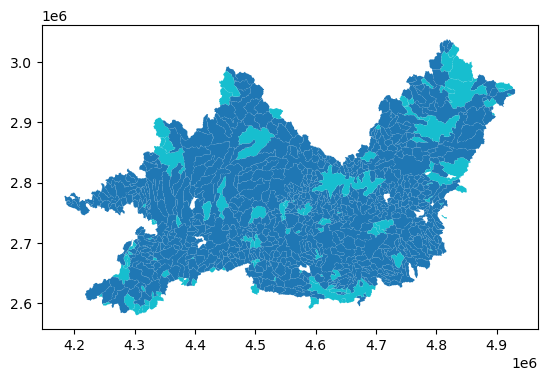

In [8]:
plot_gdf = no_na_attributes.copy().join(outliers)

plot_gdf.plot(column="label")

In [9]:
# Only conduct PCA based upon the normal basins. 
normal_basins = scaled_attributes.loc[~outliers["label"]]
outlier_basins = scaled_attributes.loc[outliers["label"]]

pca = PCA(n_components=0.8, svd_solver="full")
pca_normal_attributes = pca.fit_transform(normal_basins)

# Map outliers to same PCA space.
pca_out_attributes = pca.transform(outlier_basins)

Text(0.5, 1.0, 'DB_scores')

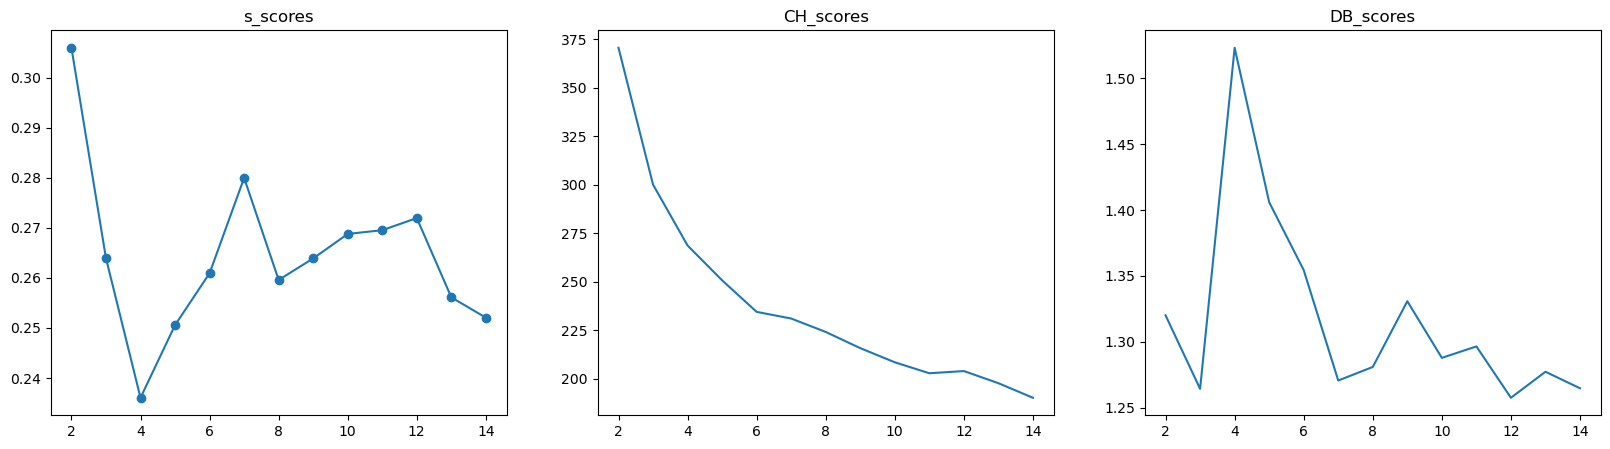

In [10]:
s_scores = []
CH_scores = []
DB_scores = []

aic_scores = []
bic_scores = []

for k in range(2,15):

    # Test for k-means.
    labels = KMeans(k,random_state=42).fit_predict(pca_normal_attributes)
    s_scores.append(silhouette_score(pca_normal_attributes,labels)) # higher is better
    CH_scores.append(calinski_harabasz_score(pca_normal_attributes,labels)) # higher is better
    DB_scores.append(davies_bouldin_score(pca_normal_attributes, labels)) # lower is better

    # Test for gmm.
    gmm = GaussianMixture(k, random_state=42)
    gmm.fit(pca_normal_attributes)
    aic_scores.append(gmm.aic(pca_normal_attributes))
    bic_scores.append(gmm.bic(pca_normal_attributes))

fig, axs = plt.subplots(1,3, figsize=(20,5))

axs[0].plot(range(2,15), s_scores, marker="o")
axs[1].plot(range(2,15), CH_scores)
axs[2].plot(range(2,15), DB_scores)

axs[0].set_title("s_scores")
axs[1].set_title("CH_scores")
axs[2].set_title("DB_scores")


In [11]:
print(f"AIC_min: {pd.Series(aic_scores).idxmin()}; BIC_min: {pd.Series(bic_scores).idxmin()}")

AIC_min: 12; BIC_min: 6


In [40]:
normal_basins.index.is_unique

True

In [46]:
bootstrap_results["10"].value_counts()

10
4.0    124
3.0    120
0.0    103
5.0     23
2.0     23
1.0      1
6.0      1
Name: count, dtype: int64

In [ ]:
bootstrap_results = pd.DataFrame(index=normal_basins.index)

kmeans = KMeans(7, random_state=42)

for n in range(0,100,10): 

    seed = np.random.seed(n)

    basin_ids = np.arange(len(normal_basins ))

    sampled_id = np.random.choice(normal_basins.index,int(len(basin_ids)*0.8))
    
    bootstrap_results.loc[sampled_id,f"{n}"] = kmeans.fit_predict(scaled_hy_id.loc[sampled_id,:])



/misc/team2/wenzel/mamba/envs/lamah-ce_lstm/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


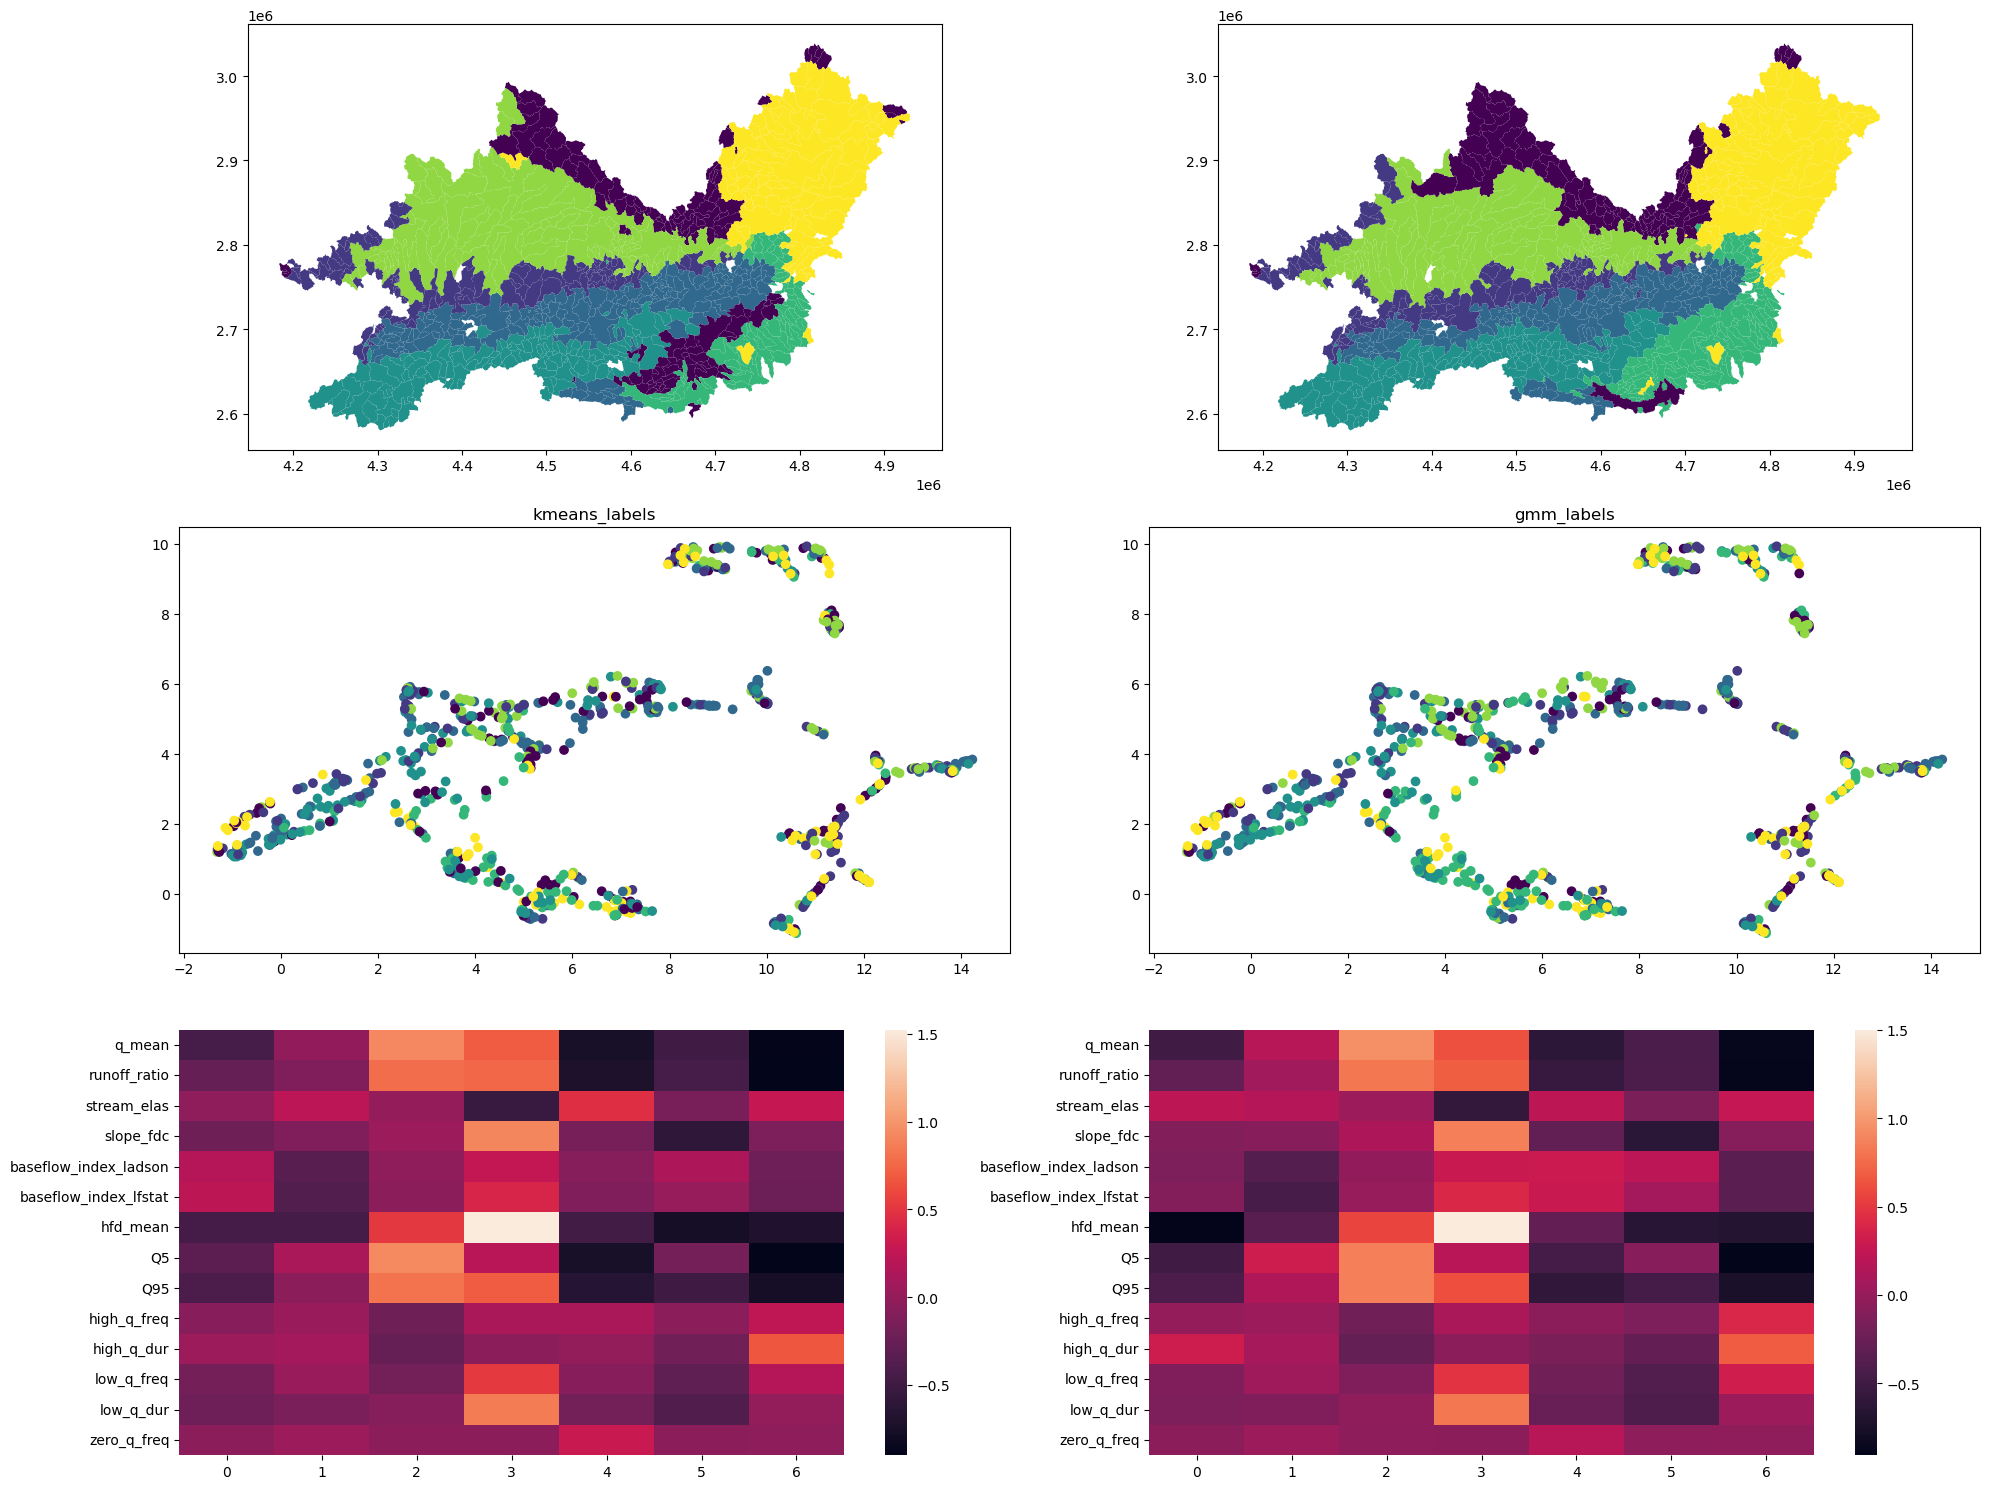

In [ ]:
n_clusters = 7
seed = 22


for n in range(10): 

    preprocessing.t
    

# KMEANS
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)

# Fit on normal basins. 
kmeans_normal_labels = pd.Series(kmeans.fit_predict(pca_normal_attributes), normal_basins.index)

# Assign outlier basins to nearest cluster centre.
kmeans_out_labels = pd.Series(kmeans.predict(pca_out_attributes), outlier_basins.index)
kmeans_labels = pd.concat([kmeans_normal_labels, kmeans_out_labels]).sort_index()

# GMM
gmm = GaussianMixture(n_components=n_clusters,random_state=seed, covariance_type="full")
gmm_normal_labels = pd.Series(gmm.fit_predict(pca_normal_attributes), normal_basins.index)
gmm_out_labels = pd.Series(gmm.predict(pca_out_attributes), outlier_basins.index)
gmm_labels = pd.concat([gmm_normal_labels, gmm_out_labels]).sort_index()

# Agglomerative Clustering
#agglo = AgglomerativeClustering(n_clusters=n_clusters)
#agglo_normal_labels = pd.Series(agglo.fit_predict(pca_normal_attributes), normal_basins.index)
#agglo_out_labels = pd.Series(agglo.predict(pca_out_attributes), outlier_basins.index)
#agglo_labels= pd.concat([agglo_normal_labels, agglo_out_labels]).sort_index()

# PLOT
plot_gdf = no_na_attributes.loc[common_ids].copy()
plot_gdf["kmeans_labels"] = kmeans_labels
plot_gdf["gmm_labels"] = gmm_labels 
#plot_gdf["agglo_labels"] = agglo_labels

# Assign one fix color for each cluster
cmap = mpl.colormaps["viridis"].resampled(n_clusters)
vmin = plot_gdf["kmeans_labels"].min()
vmax = plot_gdf["kmeans_labels"].max()

fig, axs = plt.subplots(3,2,figsize=(20,15))

plot_gdf.plot(
    ax=axs[0,0],
    column="kmeans_labels",
    cmap=cmap, vmin=vmin, vmax=vmax)

plot_gdf.plot(
    ax=axs[0,1],
    column="gmm_labels",
    cmap=cmap, vmin=vmin, vmax=vmax)

#plot_gdf.plot(
#    ax=axs[0,2],
#    column="agglo_labels",
#    cmap=cmap, vmin=vmin, vmax=vmax)

# Combine pca results of normal and outlier basins for plotting. Also apply umap, to reduce pca dimensions to 2. 
pca_all_attributes = np.concat([pca_normal_attributes, pca_out_attributes])

reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap2d = reducer.fit_transform(pca_all_attributes)
plot_gdf[["UMAP1","UMAP2"]] = umap2d

axs[1,0].scatter(plot_gdf["UMAP1"], plot_gdf["UMAP2"], c=kmeans_labels)
axs[1,1].scatter(plot_gdf["UMAP1"], plot_gdf["UMAP2"], c=gmm_labels)
#axs[1,2].scatter(pca_all_attributes[:,0], pca_all_attributes[:,1], c=agglo_labels)

axs[1,0].set_title("kmeans_labels")
axs[1,1].set_title("gmm_labels")
#axs[1,2].set_title("agglo_labels")

# Calculate mean values of hydro id per cluster group.
hy_id_mean_df = scaled_hy_id.groupby(kmeans_labels).mean()

sns.heatmap(ax=axs[2,0],data = scaled_hy_id.groupby(kmeans_labels).mean().transpose())
sns.heatmap(ax=axs[2,1],data = scaled_hy_id.groupby(gmm_labels).mean().transpose())
#sns.heatmap(ax=axs[2,2],data = scaled_hy_id.groupby(agglo_labels).mean().transpose())

plt.tight_layout()

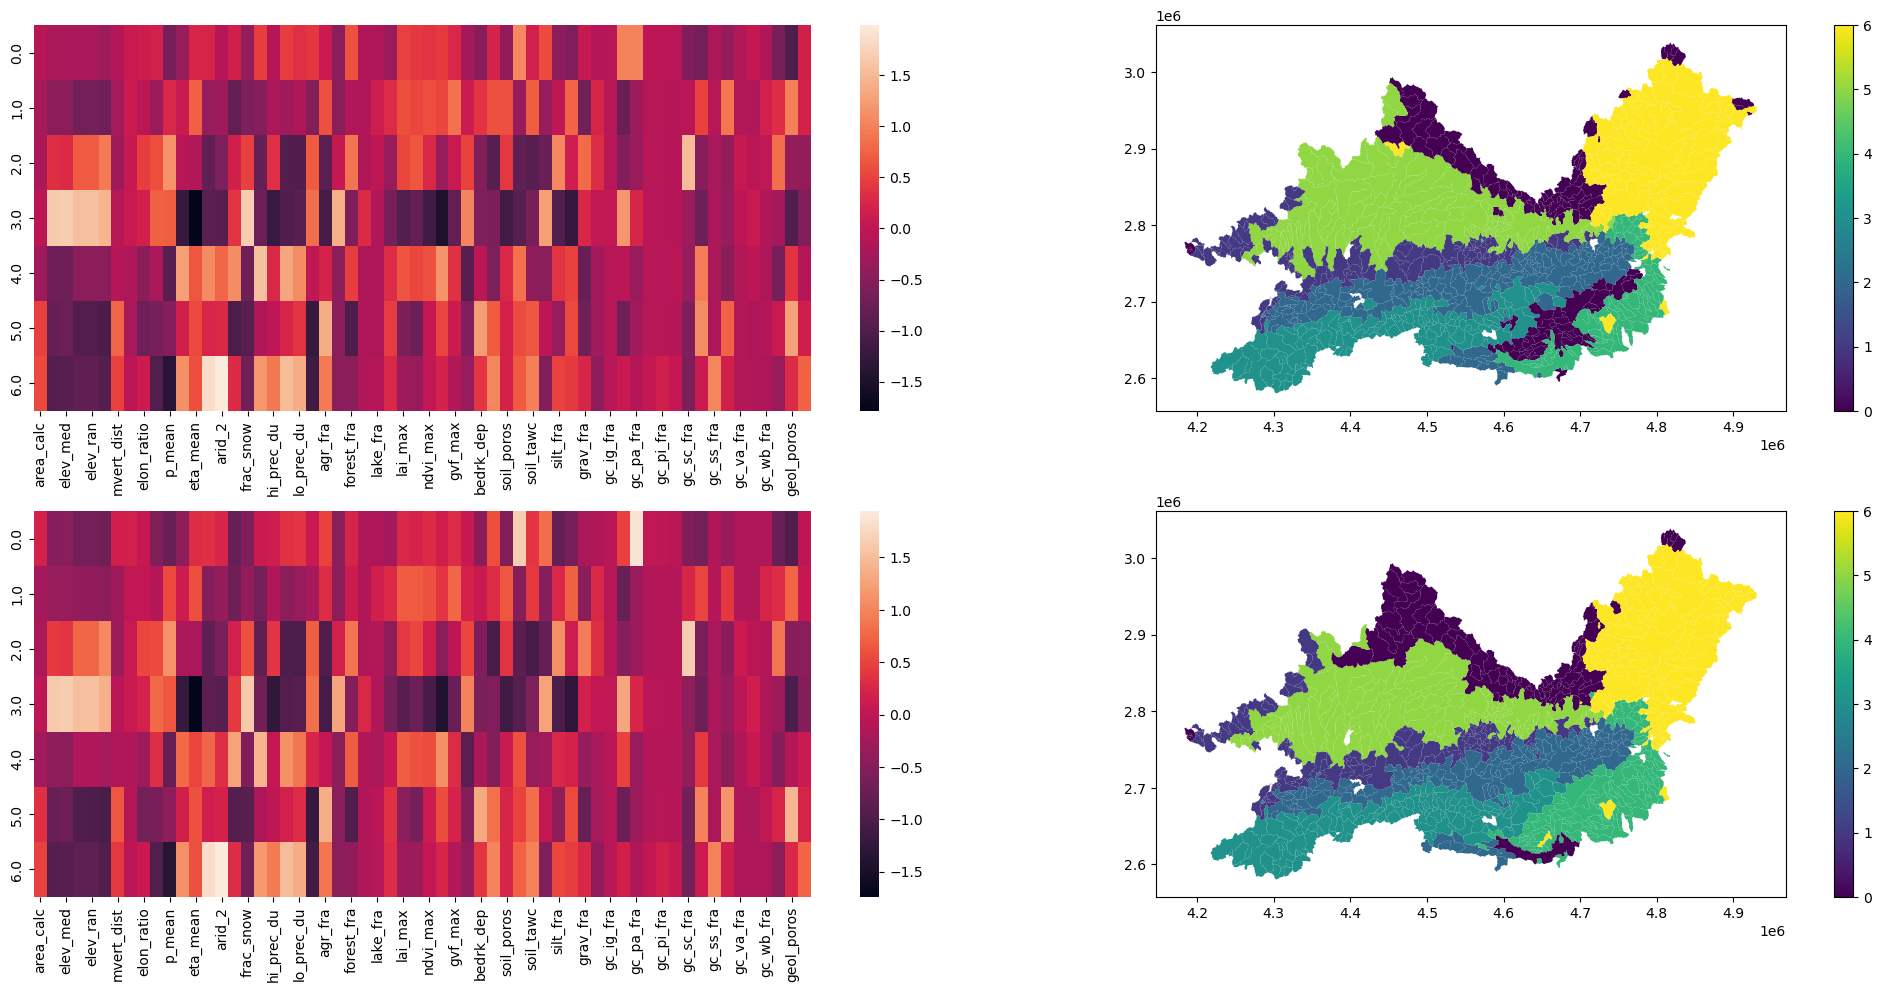

In [24]:
fig, axs = plt.subplots(2,2, figsize=(20,10))

sns.heatmap(ax=axs[0,0], data=scaled_attributes.groupby(kmeans_normal_labels).mean())
plot_gdf.plot(ax=axs[0,1], column="kmeans_labels", legend=True)
sns.heatmap(ax=axs[1,0], data=scaled_attributes.groupby(gmm_normal_labels).mean())
plot_gdf.plot(ax=axs[1,1], column="gmm_labels", legend=True)

plt.tight_layout()

In [14]:
#Check that the hy_id in each cluster are normally distributed. 

shapiro_test_results = []
var_test_results = []

for hy_id in scaled_hy_id.columns:

    groups = [scaled_hy_id.loc[kmeans_labels == cluster, hy_id] for cluster in kmeans_labels]

    var_test_results.append(stats.levene(*groups))

    for cluster in kmeans_labels.unique():

        shapiro_test_results.append(stats.shapiro(scaled_hy_id.loc[kmeans_labels == cluster, hy_id]))

# hy_id in the cluster are not normally distributed as well as not equal variance.

/misc/team2/wenzel/mamba/envs/lamah-ce_lstm/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [15]:
shapiro_test_results

[ShapiroResult(statistic=np.float64(0.8913389335565379), pvalue=np.float64(1.4313252771650378e-08)),
 ShapiroResult(statistic=np.float64(0.6899711445701513), pvalue=np.float64(8.631774829964285e-18)),
 ShapiroResult(statistic=np.float64(0.9338166864484421), pvalue=np.float64(1.9583096792141927e-05)),
 ShapiroResult(statistic=np.float64(0.9478912275471897), pvalue=np.float64(0.0014399146249162444)),
 ShapiroResult(statistic=np.float64(0.8372750656730226), pvalue=np.float64(2.1898197235633177e-09)),
 ShapiroResult(statistic=np.float64(0.9456830078826826), pvalue=np.float64(6.12993091717899e-05)),
 ShapiroResult(statistic=np.float64(0.8082791380624469), pvalue=np.float64(2.12523974070518e-09)),
 ShapiroResult(statistic=np.float64(0.9198890497690806), pvalue=np.float64(5.813913382020527e-07)),
 ShapiroResult(statistic=np.float64(0.625354959104119), pvalue=np.float64(1.8830775959177285e-19)),
 ShapiroResult(statistic=np.float64(0.9659242512831276), pvalue=np.float64(0.004314567031611609)),


In [16]:
#Create ANOVA for every hydro indices,

kruskal_results = {}

for hy_id in scaled_hy_id.columns:

    groups = [scaled_hy_id.loc[kmeans_labels == c, hy_id] for c in kmeans_labels.unique()]

    f_stat, p_val = stats.kruskal(*groups)

    kruskal_results[hy_id] = {"f": f_stat, "p": p_val}

kruskal_results

{'q_mean': {'f': np.float64(530.9971952507736),
  'p': np.float64(1.761124559615681e-111)},
 'runoff_ratio': {'f': np.float64(457.9175653674694),
  'p': np.float64(9.699342964588837e-96)},
 'stream_elas': {'f': np.float64(77.69351074373394),
  'p': np.float64(1.0692958305854967e-14)},
 'slope_fdc': {'f': np.float64(194.2561357999513),
  'p': np.float64(3.165320373055796e-39)},
 'baseflow_index_ladson': {'f': np.float64(28.70455212896109),
  'p': np.float64(6.918946684376757e-05)},
 'baseflow_index_lfstat': {'f': np.float64(50.365675677762894),
  'p': np.float64(3.9707173069384965e-09)},
 'hfd_mean': {'f': np.float64(497.44300238029),
  'p': np.float64(2.988913488505163e-104)},
 'Q5': {'f': np.float64(370.15769814609155),
  'p': np.float64(7.238585355126065e-77)},
 'Q95': {'f': np.float64(529.2441000932075),
  'p': np.float64(4.203473201205531e-111)},
 'high_q_freq': {'f': np.float64(52.81393510905315),
  'p': np.float64(1.2789968575591535e-09)},
 'high_q_dur': {'f': np.float64(107.1565

Export time periods as .pkl and basin id splits as .txt.

In [17]:
import pickle as pkl

splits_directory_path = Path("/home/wuhlmann/BA/data/processed_data/test_splits")

with open(splits_directory_path / "train.pkl", "wb") as out: 
    pkl.dump(train_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "val.pkl", "wb") as out: 
    pkl.dump(val_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "test.pkl", "wb") as out: 
    pkl.dump(test_dict, out, protocol=pkl.HIGHEST_PROTOCOL)


In [18]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
    for id in train_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
    for id in val_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
    for id in test_dict.keys():
        f.write(f"{id}\n")